# Proiect Prezicerea Umiditatii Solului

## Introducere

Acest proiect își propune să analizeze și să prezică umiditatea solului 
folosind date meteorologice zilnice colectate în zona lacului Urmia, Iran.

Umiditatea solului joacă un rol esențial în agricultură, hidrologie și 
gestionarea resurselor de apă, iar predicția acesteia pe baza parametrilor 
meteorologici poate contribui la o mai bună planificare în aceste domenii.

În cadrul proiectului se vor realiza:
- Încărcarea și curățarea datelor
- Analiza și vizualizarea datelor
- Construirea unui model de predicție bazat pe Machine Learning

Încărcarea datelor din excel în proiect.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Dataset/urmia.xlsx", usecols=range(11))
df.head()

,Date,Month,Day,Tmax,Tmin,Tmean,RHmax,RHmin,SSHtime,U,P24
0,1993-01-01,1,1,1.8,-10.0,-5.3,66.0,45.0,1.2,0.375,0.00
1,1993-01-02,1,2,0.4,-9.2,-4.6,60.0,51.0,4.4,0.500,0.00
2,1993-01-03,1,3,1.2,-2.6,-2.2,75.0,58.0,1.2,0.500,0.00
3,1993-01-04,1,4,0.0,-5.6,-2.0,95.0,84.0,0.0,0.125,0.50
4,1993-01-05,1,5,-1.6,-3.0,-2.4,95.0,72.0,0.0,0.250,1.31


Aanaliză scurtă a datelor.

In [22]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10957 entries, 0 to 10956
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     10957 non-null  datetime64[us]
 1   Month    10957 non-null  int64         
 2   Day      10957 non-null  int64         
 3   Tmax     10957 non-null  float64       
 4   Tmin     10957 non-null  float64       
 5   Tmean    10957 non-null  float64       
 6   RHmax    10957 non-null  float64       
 7   RHmin    10957 non-null  float64       
 8   SSHtime  10957 non-null  float64       
 9   U        10957 non-null  float64       
 10  P24      10957 non-null  float64       
dtypes: datetime64[us](1), float64(8), int64(2)
memory usage: 941.7 KB


,Date,Month,Day,Tmax,Tmin,Tmean,RHmax,RHmin,SSHtime,U,P24
count,10957,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000
mean,2008-01-01 00:00:00,6.523136,15.729032,18.589363,5.414501,11.793334,77.971148,38.079785,8.126095,2.269452,0.849152
min,1993-01-01 00:00:00,1.000000,1.000000,-7.200000,-18.200000,-12.900000,29.000000,3.000000,0.000000,0.000000,0.000000
25%,2000-07-02 00:00:00,4.000000,8.000000,9.600000,-1.200000,3.600000,68.000000,26.000000,5.500000,1.625000,0.000000
50%,2008-01-01 00:00:00,7.000000,16.000000,19.200000,6.000000,12.200000,79.000000,35.000000,9.100000,2.250000,0.000000
75%,2015-07-02 00:00:00,10.000000,23.000000,28.200000,12.400000,20.500000,90.000000,48.000000,11.400000,2.875000,0.000000
max,2022-12-31 00:00:00,12.000000,31.000000,39.900000,23.700000,30.000000,100.000000,98.000000,14.500000,9.250000,61.010000
std,NaN,3.448804,8.800238,10.514357,8.146448,9.509118,14.047053,16.729460,3.973020,1.079479,3.389282


Verificare dacă există date lipsă.

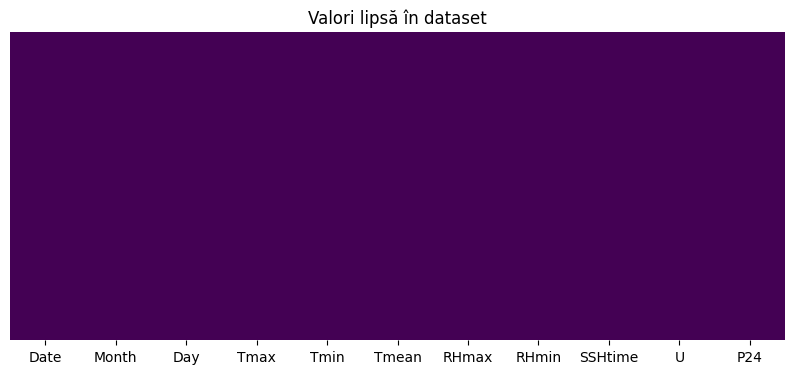

In [20]:
df.isnull().sum()

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Valori lipsă în dataset")
plt.show()

Curățarea anomaliilor din setul de date.

Rânduri înainte: 10957
Rânduri după: 10573
            Date  Month  Day  Tmax  Tmin  Tmean  RHmax  RHmin  SSHtime      U  \
7     1993-01-08      1    8   3.2  -4.8   -2.1   97.0   71.0      4.6  0.125   
32    1993-02-02      2    2   1.4  -7.2   -2.4   98.0   92.0      0.0  0.000   
50    1993-02-20      2   20   1.0  -7.6   -2.8   96.0   77.0      0.0  0.000   
61    1993-03-03      3    3   3.0  -4.2   -1.3   98.0   87.0      1.5  0.375   
65    1993-03-07      3    7   5.0  -1.6    1.0   96.0   67.0      0.0  0.000   
...          ...    ...  ...   ...   ...    ...    ...    ...      ...    ...   
10711 2022-04-30      4   30  20.3   8.6   13.3   95.0   48.0      7.2  2.500   
10820 2022-08-17      8   17  36.4  15.4   27.7   34.0   19.0     10.3  2.375   
10835 2022-09-01      9    1  34.0  15.5   24.7   35.0   14.0     11.5  2.500   
10921 2022-11-26     11   26  11.0   2.9    6.1  100.0   72.0      2.4  2.000   
10925 2022-11-30     11   30   6.8   3.1    5.6  100.0   94.0     

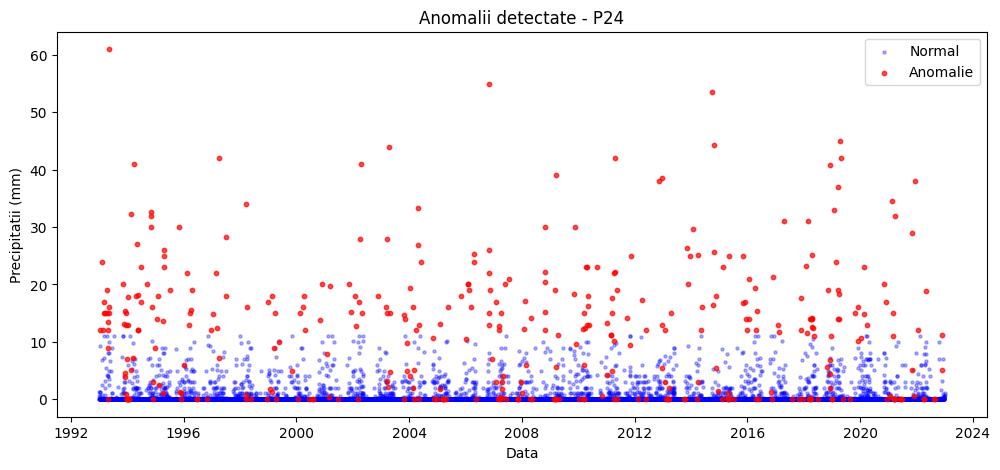

In [19]:
from scipy import stats

z_scores = stats.zscore(df[cols])
mask = (abs(z_scores) < 3).all(axis=1)
df_clean = df[mask]

print(f"Rânduri înainte: {len(df)}")
print(f"Rânduri după: {len(df_clean)}")

mask_anomalii = (abs(z_scores) >= 3).any(axis=1)
df_anomalii = df[mask_anomalii]
print(df_anomalii)

plt.figure(figsize=(12, 5))
plt.scatter(df_clean['Date'], df_clean['P24'], color='blue', alpha=0.3, s=5, label='Normal')
plt.scatter(df_anomalii['Date'], df_anomalii['P24'], color='red', alpha=0.7, s=10, label='Anomalie')
plt.title("Anomalii detectate - P24")
plt.xlabel("Data")
plt.ylabel("Precipitatii (mm)")
plt.legend()
plt.show()

## Descrierea bazei de date

Baza de date conține date meteorologice zilnice colectate în zona lacului Urmia din Iran, 
acoperind perioada **1993 - 2022**, cu un total de **10957 înregistrări**.

### Coloane

| Coloană | Descriere |
|--------|-----------|
| Date | Data înregistrării |
| Month | Luna (1-12) |
| Day | Ziua (1-31) |
| Tmax | Temperatura maximă zilnică (°C) |
| Tmin | Temperatura minimă zilnică (°C) |
| Tmean | Temperatura medie zilnică (°C) |
| RHmax | Umiditatea relativă maximă (%) |
| RHmin | Umiditatea relativă minimă (%) |
| SSHtime | Durata strălucirii solare (ore) |
| U | Viteza vântului (m/s) |
| P24 | Precipitații zilnice (mm) |

### Curățare

Nu au fost găsite valori lipsă în dataset. Anomaliile au fost eliminate folosind metoda 
**Z-score** (prag = 3), rezultând **10573 înregistrări** după curățare.

## Gini index

Distributia categoriilor:
P24_cat
Fara ploaie    0.837038
Ploaie mica    0.159179
Ploaie mare    0.003783
Name: proportion, dtype: float64

Gini Index pentru P24: 0.2740


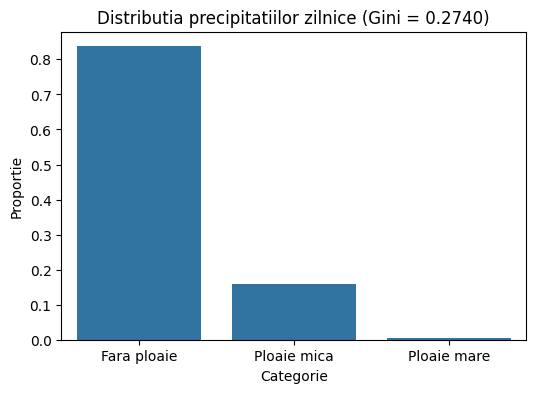

In [18]:
# Împărțim P24 în categorii
bins = [0, 0.1, 10, 100]
labels = ['Fara ploaie', 'Ploaie mica', 'Ploaie mare']
df_clean['P24_cat'] = pd.cut(df_clean['P24'], bins=bins, labels=labels, include_lowest=True)

# Calculam Gini index
proportii = df_clean['P24_cat'].value_counts(normalize=True)
gini = 1 - sum(proportii**2)

print("Distributia categoriilor:")
print(proportii)
print(f"\nGini Index pentru P24: {gini:.4f}")

plt.figure(figsize=(6, 4))
sns.barplot(x=proportii.index, y=proportii.values)
plt.title(f"Distributia precipitatiilor zilnice (Gini = {gini:.4f})")
plt.xlabel("Categorie")
plt.ylabel("Proportie")
plt.show()

## Information Quantity (Entropia)

Information Quantity măsoară cantitatea de informație dintr-o variabilă. 
Cu cât entropia e mai mare, cu atât variabila e mai impredictibilă și mai variată.
Formula: H = -Σ p(x) * log2(p(x))

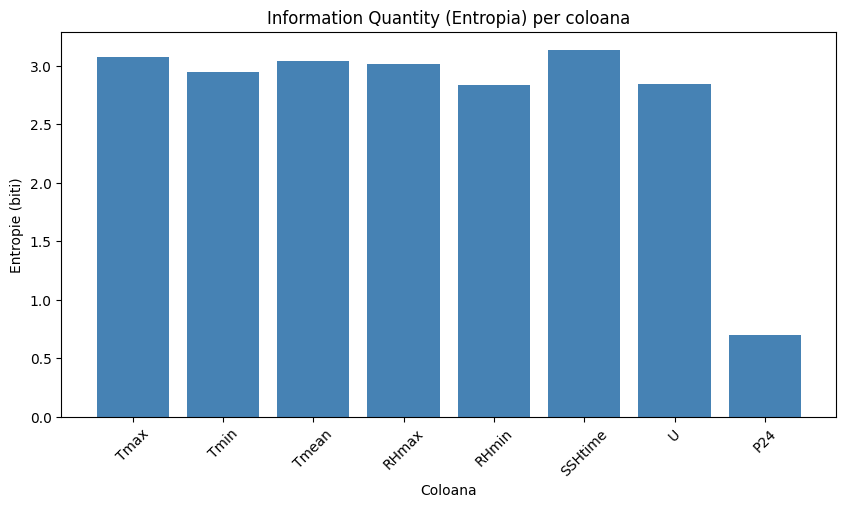

Tmax: 3.0720 biti
Tmin: 2.9440 biti
Tmean: 3.0448 biti
RHmax: 3.0153 biti
RHmin: 2.8370 biti
SSHtime: 3.1327 biti
U: 2.8446 biti
P24: 0.6980 biti


In [23]:
import numpy as np

def entropia(coloana, bins=10):
    counts, _ = np.histogram(coloana, bins=bins)
    proportii = counts / counts.sum()
    proportii = proportii[proportii > 0]
    return -np.sum(proportii * np.log2(proportii))

entropii = {col: entropia(df_clean[col]) for col in cols}

plt.figure(figsize=(10, 5))
plt.bar(entropii.keys(), entropii.values(), color='steelblue')
plt.title("Information Quantity (Entropia) per coloana")
plt.xlabel("Coloana")
plt.ylabel("Entropie (biti)")
plt.xticks(rotation=45)
plt.show()

for col, val in entropii.items():
    print(f"{col}: {val:.4f} biti")